# Quantum models as Fourier series

這是 Janus 在閱讀 "[Quantum models as Fourier series]("https://pennylane.ai/qml/demos/tutorial_expressivity_fourier_series")" 時的筆記

定義給 training 用的 loss function

In [3]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np

np.random.seed(42)


def square_loss(targets, predictions):
    loss = 0
    for t, p in zip(targets, predictions):
        loss += (t - p) ** 2
    loss = loss / len(targets)
    return 0.5 * loss

## Part I: Fitting Fourier series with serial Pauli-rotation encoding

### Define a target function

In [4]:
degree = 1  # degree of the target function
scaling = 1  # scaling of the data
coeffs = [0.15 + 0.15j] * degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency


def target_function(x):
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = coeff0
    for idx, coeff in enumerate(coeffs):
        exponent = np.complex128(scaling * (idx + 1) * x * 1j)
        conj_coeff = np.conjugate(coeff)
        res += coeff * np.exp(exponent) + conj_coeff * np.exp(-exponent)
    return np.real(res)


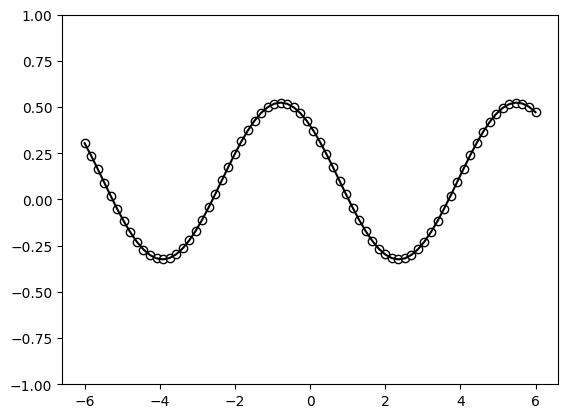

In [5]:
x = np.linspace(-6, 6, 70, requires_grad=False)
target_y = np.array([target_function(x_) for x_ in x], requires_grad=False)

plt.plot(x, target_y, c="black")
plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.ylim(-1, 1)
plt.show()

### Define the serial quantum model

In [6]:
scaling = 1

dev = qml.device("default.qubit", wires=1)


def S(x):
    """Data-encoding circuit block."""
    qml.RX(scaling * x, wires=0)


def W(theta):
    """Trainable circuit block."""
    qml.Rot(theta[0], theta[1], theta[2], wires=0)


@qml.qnode(dev)
def serial_quantum_model(weights, x):

    for theta in weights[:-1]:
        W(theta)
        S(x)

    # (L+1)'th unitary
    W(weights[-1])

    return qml.expval(qml.PauliZ(wires=0))


You can run the following cell multiple times, each time sampling different weights, and therefore different quantum models.

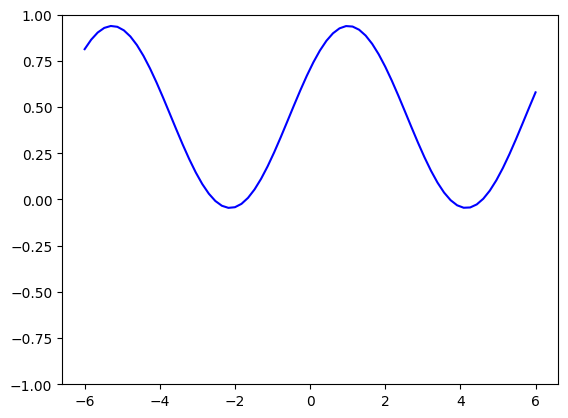

In [7]:
r = 1  # number of times the encoding gets repeated (here equal to the number of layers)
weights = (
    2 * np.pi * np.random.random(size=(r + 1, 3), requires_grad=True)
)  # some random initial weights

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [serial_quantum_model(weights, x_) for x_ in x]

plt.plot(x, random_quantum_model_y, c="blue")
plt.ylim(-1, 1)
plt.show()

### Fit the model to the target

In [8]:
def cost(weights, x, y):
    predictions = [serial_quantum_model(weights, x_) for x_ in x]
    return square_loss(y, predictions)


max_steps = 50
opt = qml.AdamOptimizer(0.3)
batch_size = 25
cst = [cost(weights, x, target_y)]  # initial cost

for step in range(max_steps):

    # Select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # Update the weights by one optimizer step
    weights, _, _ = opt.step(cost, weights, x_batch, y_batch)

    # Save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cst.append(c)
    if (step + 1) % 10 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step  10: 0.11428002647555721
Cost at step  20: 0.01264068345472531
Cost at step  30: 0.0021405817315259695
Cost at step  40: 0.0019322449091532523
Cost at step  50: 0.00013360533241902456


To continue training, you may just run the above cell again. Once you are happy, you can use the trained model to predict function values, and compare them with the ground truth.

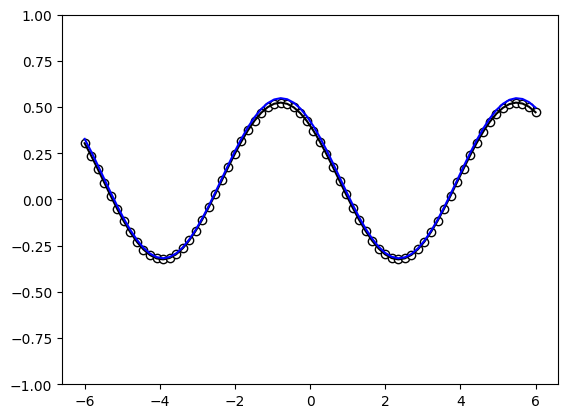

In [9]:
predictions = [serial_quantum_model(weights, x_) for x_ in x]

plt.plot(x, target_y, c="black")
plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.plot(x, predictions, c="blue")
plt.ylim(-1, 1)
plt.show()

Let’s also have a look at the cost during training.

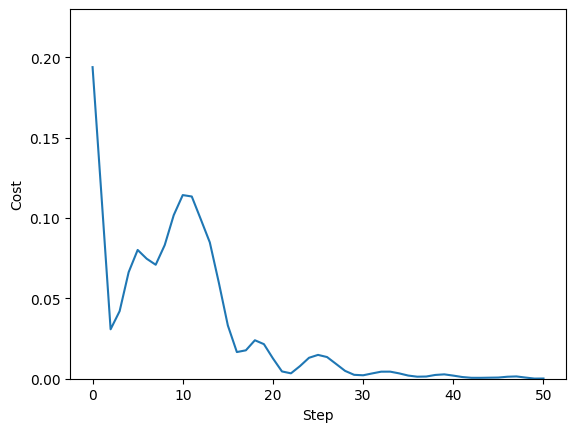

In [10]:
plt.plot(range(len(cst)), cst)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.ylim(0, 0.23)
plt.show()

## Part II: Fitting Fourier series with parallel Pauli-rotation encoding

### Define the parallel quantum model

In [11]:
from pennylane.templates import StronglyEntanglingLayers

In [12]:
n_ansatz_layers = 2
n_qubits = 3

dev = qml.device("default.qubit", wires=4)


@qml.qnode(dev)
def ansatz(weights):
    StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.Identity(wires=0))


weights_ansatz = 2 * np.pi * np.random.random(size=(n_ansatz_layers, n_qubits, 3))
print(qml.draw(ansatz, level="device")(weights_ansatz))

0: ──Rot(0.69,5.62,6.23)─╭●────╭X──Rot(3.42,5.43,4.61)─╭●─╭X────┤  <I>
1: ──Rot(0.39,5.55,3.24)─╰X─╭●─│───Rot(3.28,5.45,1.54)─│──╰●─╭X─┤     
2: ──Rot(5.70,3.59,4.16)────╰X─╰●──Rot(0.99,1.01,2.10)─╰X────╰●─┤     


Now we define the actual quantum model.

In [13]:
scaling = 1
r = 3

dev = qml.device("default.qubit", wires=r)


def S(x):
    """Data-encoding circuit block."""
    for w in range(r):
        qml.RX(scaling * x, wires=w)


def W(theta):
    """Trainable circuit block."""
    StronglyEntanglingLayers(theta, wires=range(r))


@qml.qnode(dev)
def parallel_quantum_model(weights, x):

    W(weights[0])
    S(x)
    W(weights[1])

    return qml.expval(qml.PauliZ(wires=0))


Again, you can sample random weights and plot the model function:

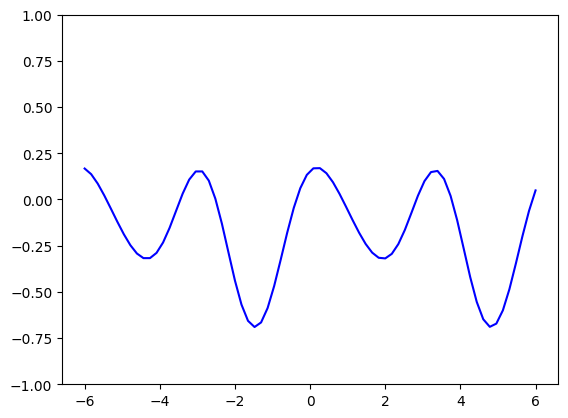

In [14]:
trainable_block_layers = 3
weights = 2 * np.pi * np.random.random(size=(2, trainable_block_layers, r, 3), requires_grad=True)

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [parallel_quantum_model(weights, x_) for x_ in x]

plt.plot(x, random_quantum_model_y, c="blue")
plt.ylim(-1, 1)
plt.show()

### Training the model

Training the model is done exactly as before, but it may take a lot longer this time. We set a default of 70 steps, which you should increase if necessary. Small models of <6 qubits usually converge after a few hundred steps at most—but this depends on your settings.

In [15]:
def cost(weights, x, y):
    predictions = [parallel_quantum_model(weights, x_) for x_ in x]
    return square_loss(y, predictions)


max_steps = 70
opt = qml.AdamOptimizer(0.3)
batch_size = 25
cst = [cost(weights, x, target_y)]  # initial cost

for step in range(max_steps):

    # select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # update the weights by one optimizer step
    weights, _, _ = opt.step(cost, weights, x_batch, y_batch)

    # save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cst.append(c)
    if (step + 1) % 10 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step  10: 0.024742300200735718
Cost at step  20: 0.010715703200828864
Cost at step  30: 0.006796849973368072
Cost at step  40: 0.00917559377619717
Cost at step  50: 0.011346436503632542
Cost at step  60: 0.0033654112493889028
Cost at step  70: 0.0007606196425140255


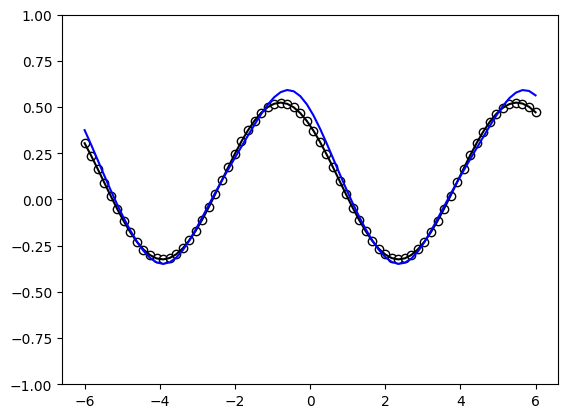

In [16]:
predictions = [parallel_quantum_model(weights, x_) for x_ in x]

plt.plot(x, target_y, c="black")
plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.plot(x, predictions, c="blue")
plt.ylim(-1, 1)
plt.show()

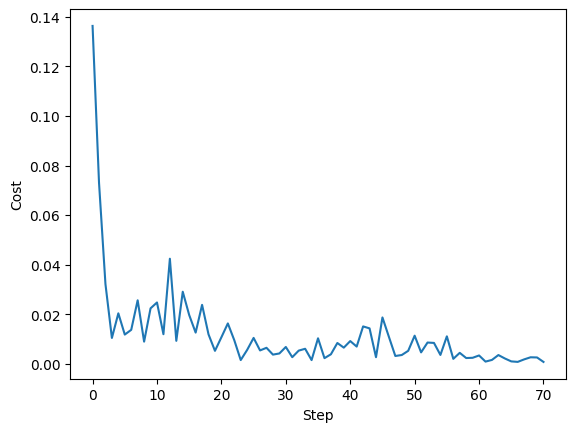

In [17]:
plt.plot(range(len(cst)), cst)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.show()

## Part III: Sampling Fourier coefficients

When we use a trainable ansatz above, it is possible that even with enough repetitions of the data-encoding Pauli rotation, the quantum model cannot fit the circuit, since the expressivity of quantum models also depends on the Fourier coefficients the model can create.

Figure 5 in [1] shows Fourier coefficients from quantum models sampled from a model family defined by an ansatz for the trainable circuit block. For this we need a function that numerically computes the Fourier coefficients of a periodic function f with period $2\pi$.

In [19]:
def fourier_coefficients(f, K):
    """
    Computes the first 2*K+1 Fourier coefficients of a 2*pi periodic function.
    """
    n_coeffs = 2 * K + 1
    t = np.linspace(0, 2 * np.pi, n_coeffs, endpoint=False)
    y = np.fft.rfft(f(t)) / t.size
    return y

### Define your quantum model

Now we need to define a quantum model. This could be any model, using a qubit or continuous-variable circuit, or one of the quantum models from above. We will use a slight derivation of the `parallel_qubit_model()` from above, this time using the `BasicEntanglerLayers` ansatz:

In [20]:
from pennylane.templates import BasicEntanglerLayers

scaling = 1
n_qubits = 4

dev = qml.device("default.qubit", wires=n_qubits)


def S(x):
    """Data encoding circuit block."""
    for w in range(n_qubits):
        qml.RX(scaling * x, wires=w)


def W(theta):
    """Trainable circuit block."""
    BasicEntanglerLayers(theta, wires=range(n_qubits))


@qml.qnode(dev)
def quantum_model(weights, x):

    W(weights[0])
    S(x)
    W(weights[1])

    return qml.expval(qml.PauliZ(wires=0))

It will also be handy to define a function that samples different random weights of the correct size for the model.

In [21]:
n_ansatz_layers = 1


def random_weights():
    return 2 * np.pi * np.random.random(size=(2, n_ansatz_layers, n_qubits))

Now we can compute the first few Fourier coefficients for samples from this model. The samples are created by randomly sampling different parameters using the `random_weights()` function.

In [22]:
n_coeffs = 5
n_samples = 100


coeffs = []
for i in range(n_samples):

    weights = random_weights()

    def f(x):
        return np.array([quantum_model(weights, x_) for x_ in x])

    coeffs_sample = fourier_coefficients(f, n_coeffs)
    coeffs.append(coeffs_sample)

coeffs = np.array(coeffs)
coeffs_real = np.real(coeffs)
coeffs_imag = np.imag(coeffs)

Let’s plot the real vs. the imaginary part of the coefficients. As a sanity check, the $c_0$ coefficient should be real, and therefore have no contribution on the y-axis.

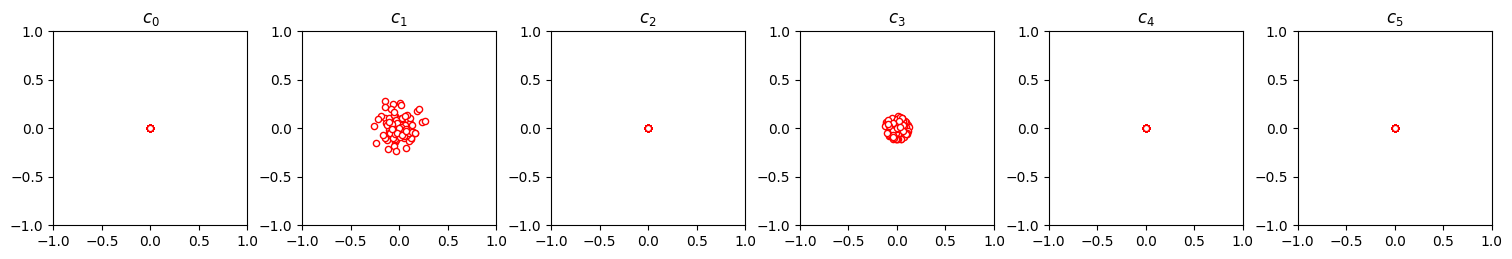

In [23]:
n_coeffs = len(coeffs_real[0])

fig, ax = plt.subplots(1, n_coeffs, figsize=(15, 4))

for idx, ax_ in enumerate(ax):
    ax_.set_title(r"$c_{}$".format(idx))
    ax_.scatter(
        coeffs_real[:, idx],
        coeffs_imag[:, idx],
        s=20,
        facecolor="white",
        edgecolor="red",
    )
    ax_.set_aspect("equal")
    ax_.set_ylim(-1, 1)
    ax_.set_xlim(-1, 1)


plt.tight_layout(pad=0.5)
plt.show()

Playing around with different quantum models, you will find that some quantum models create different distributions over the coefficients than others. For example `BasicEntanglingLayers` (with the default Pauli-X rotation) seems to have a structure that forces the even Fourier coefficients to zero, while `StronglyEntanglingLayers` will have a non-zero variance for all supported coefficients.

Note also how the variance of the distribution decreases for growing orders of the coefficients—an effect linked to the convergence of a Fourier series.

### Continuous-variable model

Ref. [1] mentions that a phase rotation in continuous-variable quantum computing has a spectrum that supports all Fourier frequecies. To play with this model, we finally show you the code for a continuous-variable circuit. For example, to see its Fourier coefficients run the cell below, and then re-run the two cells above.

In [24]:
var = 2
n_ansatz_layers = 1
dev_cv = qml.device("default.gaussian", wires=1)


def S(x):
    qml.Rotation(x, wires=0)


def W(theta):
    """Trainable circuit block."""
    for r_ in range(n_ansatz_layers):
        qml.Displacement(theta[0], theta[1], wires=0)
        qml.Squeezing(theta[2], theta[3], wires=0)


@qml.qnode(dev_cv)
def quantum_model(weights, x):
    W(weights[0])
    S(x)
    W(weights[1])
    return qml.expval(qml.QuadX(wires=0))


def random_weights():
    return np.random.normal(size=(2, 5 * n_ansatz_layers), loc=0, scale=var)

## References

* Maria Schuld, Ryan Sweke, and Johannes Jakob Meyer. “The effect of data encoding on the expressive power of variational quantum machine learning models.” [arXiv:2008.08605]("https://arxiv.org/abs/2008.08605") (2020).